# 08 - Explainable AI: SHAP, Anchors, and Counterfactuals

This notebook explains the champion credit-risk model selected in Notebook 06 and converted into an operating decision rule in Notebook 07.

The goal is not only to show feature importance. The goal is to produce explanations that are useful for three audiences:

- **Risk analytics / data science:** Which variables drive ranking performance?
- **Credit-risk stakeholders:** Why was a borrower sent to manual review?
- **Model governance / validation:** Are explanations consistent, auditable, and free from obvious leakage?

## Professional framing

For a Canadian retail credit-risk portfolio, explainability should support responsible model use. SHAP provides global and local contribution analysis, anchor-like rules translate selected decisions into business-readable conditions, and counterfactual scenarios show how selected changes could move an account below the operating threshold.

Important governance note: counterfactuals are **scenario diagnostics**, not automatic lending advice. Some scenarios, such as historical delinquency removal, are non-actionable and are retained only to explain model sensitivity.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from credit_risk.explainability.anchors_analysis import build_anchor_like_rules
from credit_risk.explainability.counterfactuals import (
    best_counterfactual_per_account,
    generate_counterfactual_scenarios,
)
from credit_risk.explainability.shap_analysis import (
    compute_tree_shap_values,
    get_model_split,
    individual_top_contributions,
    load_explainability_artifacts,
    plot_global_shap_bar,
    plot_numeric_shap_dependence,
    predict_scores,
    select_explanation_sample,
    summarize_global_shap,
    summarize_grouped_shap,
    summarize_probability_deciles,
)

TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "reports" / "model_artifacts"
DATA_DIR = PROJECT_ROOT / "data" / "processed"

## Load champion model and operating threshold

This notebook uses the saved champion pipeline, the modelling dataset, the feature metadata, and the recommended threshold selected on the validation split.

In [2]:
artifacts = load_explainability_artifacts(
    model_path=MODEL_DIR / "champion_model.joblib",
    metadata_path=MODEL_DIR / "model_feature_metadata.joblib",
    modeling_dataset_path=DATA_DIR / "credit_risk_modeling_dataset.csv",
    recommended_threshold_path=TABLE_DIR / "recommended_threshold_summary.csv",
)

{
    "champion_model_name": artifacts.champion_model_name,
    "operating_threshold": artifacts.recommended_threshold,
    "modeling_rows": len(artifacts.modeling_df),
    "modeling_columns": artifacts.modeling_df.shape[1],
}

{'champion_model_name': 'xgboost_weighted',
 'operating_threshold': 0.565,
 'modeling_rows': 134417,
 'modeling_columns': 51}

## Prepare test split for explanations

Explanations are produced on the held-out test split. This keeps the interpretation aligned with out-of-sample model behaviour rather than training data memorization.

In [3]:
X_test, y_test, identity_test = get_model_split(
    artifacts.modeling_df,
    artifacts.metadata,
    split_name="test",
)

scores = predict_scores(artifacts.champion_model, X_test)
score_series = pd.Series(scores, index=X_test.index, name="predicted_default_probability")

probability_deciles = summarize_probability_deciles(
    y_true=y_test,
    scores=scores,
    threshold=artifacts.recommended_threshold,
)

{
    "test_rows": len(X_test),
    "test_default_rate": y_test.mean(),
    "average_predicted_probability": float(score_series.mean()),
    "review_rate_at_operating_threshold": float((score_series >= artifacts.recommended_threshold).mean()),
}

{'test_rows': 20163,
 'test_default_rate': 0.09041313296632446,
 'average_predicted_probability': 0.4147838056087494,
 'review_rate_at_operating_threshold': 0.29112731240390816}

In [4]:
probability_deciles

,score_decile,row_count,average_score,min_score,max_score,observed_default_rate,review_rate_at_threshold
0,"(0.00869, 0.117]",2017,0.080084,0.009687,0.116574,0.014874,0.00000
1,"(0.117, 0.188]",2016,0.151388,0.116588,0.188010,0.018849,0.00000
2,"(0.188, 0.268]",2016,0.227104,0.188074,0.267947,0.029266,0.00000
3,"(0.268, 0.345]",2016,0.307616,0.267977,0.344931,0.042163,0.00000
4,"(0.345, 0.416]",2017,0.380237,0.344963,0.416431,0.046108,0.00000
5,"(0.416, 0.487]",2016,0.452839,0.416432,0.487099,0.075397,0.00000
6,"(0.487, 0.558]",2016,0.521516,0.487149,0.557830,0.116567,0.00000
7,"(0.558, 0.632]",2016,0.595732,0.557836,0.631881,0.128472,0.91121
8,"(0.632, 0.705]",2016,0.668757,0.631908,0.704549,0.177579,1.00000
9,"(0.705, 0.883]",2017,0.762575,0.704557,0.883060,0.254834,1.00000


## Compute SHAP values

For runtime control, SHAP is computed on a representative sample of the test split plus an oversample of the highest-risk accounts. This gives stable global insights while still including the accounts most likely to be reviewed by the business.

In [5]:
sample_indices = select_explanation_sample(
    X=X_test,
    y=y_test,
    scores=scores,
    max_rows=1500,
    high_risk_rows=250,
    random_state=42,
)

X_sample = X_test.loc[sample_indices].copy()
shap_df, transformed_X = compute_tree_shap_values(artifacts.champion_model, X_sample)

{
    "shap_sample_rows": len(X_sample),
    "transformed_feature_count": transformed_X.shape[1],
    "shap_matrix_shape": shap_df.shape,
}

{'shap_sample_rows': 1500,
 'transformed_feature_count': 47,
 'shap_matrix_shape': (1500, 47)}

## Global SHAP feature importance

The table below ranks features by mean absolute SHAP contribution. Larger values indicate stronger average influence on the model score.

In [6]:
global_importance = summarize_global_shap(shap_df)
grouped_importance = summarize_grouped_shap(global_importance)

global_importance.head(20)

,transformed_feature,raw_feature,feature_label,mean_abs_shap,mean_shap,positive_contribution_share
0,numeric__interest_rate,interest_rate,Interest Rate,0.618882,-0.054802,0.542667
1,numeric__amount_missing_flag,amount_missing_flag,Amount Missing Flag,0.358383,0.080368,0.280667
2,numeric__broad_data_quality_issue_count,broad_data_quality_issue_count,Broad Data Quality Issue Count,0.170565,-0.050188,0.128000
3,numeric__total_income_pa,total_income_pa,Total Income Pa,0.138081,-0.019256,0.539333
4,numeric__core_data_quality_issue_count,core_data_quality_issue_count,Core Data Quality Issue Count,0.085640,-0.065911,0.702000
5,categorical__loan_to_income_band,loan_to_income_band,Loan To Income Band,0.073130,0.023619,0.290667
6,numeric__high_interest_flag,high_interest_flag,High Interest Flag,0.072073,0.014624,0.300667
7,numeric__tenure_years,tenure_years,Tenure Years,0.059983,-0.011390,0.632667
8,categorical__loan_category,loan_category,Loan Category,0.053363,0.000129,0.566000
9,numeric__amount,amount,Amount,0.043531,-0.016452,0.542667


In [7]:
grouped_importance.head(20)

,raw_feature,feature_label,mean_abs_shap,mean_shap,transformed_feature_count
0,interest_rate,Interest Rate,0.618882,-0.054802,1
1,amount_missing_flag,Amount Missing Flag,0.358383,0.080368,1
2,broad_data_quality_issue_count,Broad Data Quality Issue Count,0.170565,-0.050188,1
3,total_income_pa,Total Income Pa,0.138081,-0.019256,1
4,core_data_quality_issue_count,Core Data Quality Issue Count,0.085640,-0.065911,1
5,loan_to_income_band,Loan To Income Band,0.073130,0.023619,1
6,high_interest_flag,High Interest Flag,0.072073,0.014624,1
7,tenure_years,Tenure Years,0.059983,-0.011390,1
8,loan_category,Loan Category,0.053363,0.000129,1
9,amount,Amount,0.043531,-0.016452,1


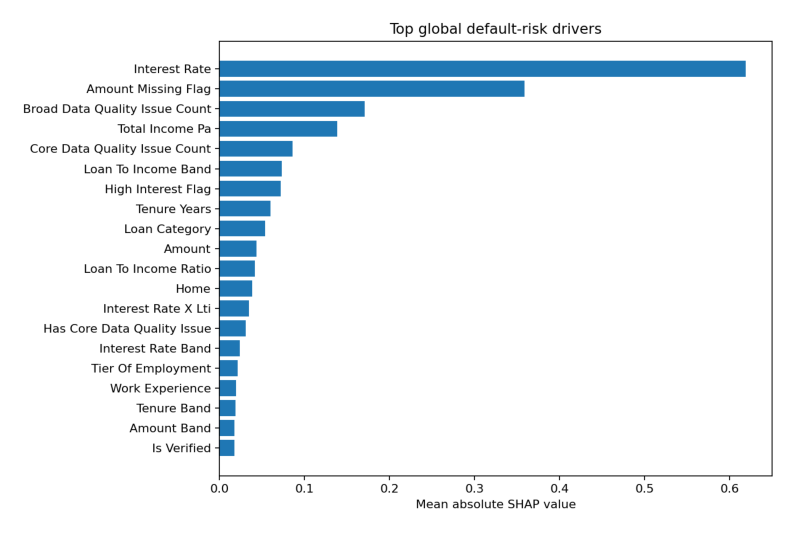

In [8]:
plot_global_shap_bar(global_importance, FIGURE_DIR / "xai_global_shap_top_features.png", top_n=20)

img = plt.imread(FIGURE_DIR / "xai_global_shap_top_features.png")
plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off");

## SHAP dependence-style plots

These plots show how selected numeric variables contribute to the default-risk score across borrowers. Values above zero push the model toward higher predicted default risk; values below zero push the model toward lower predicted default risk.

In [9]:
for feature in ["interest_rate", "loan_to_income_ratio", "total_income_pa"]:
    plot_numeric_shap_dependence(
        shap_df=shap_df,
        X_raw=X_test.loc[shap_df.index],
        raw_feature=feature,
        output_path=FIGURE_DIR / f"xai_shap_dependence_{feature}.png",
    )

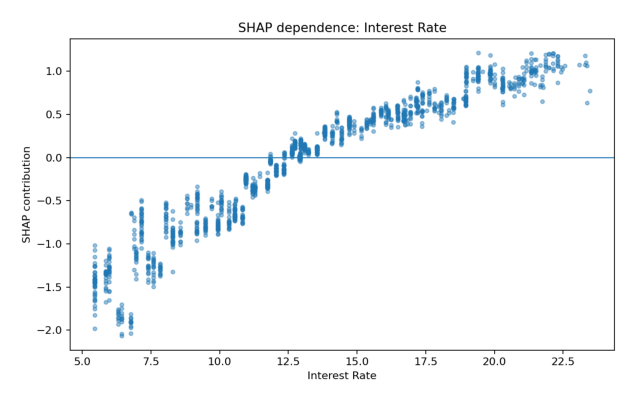

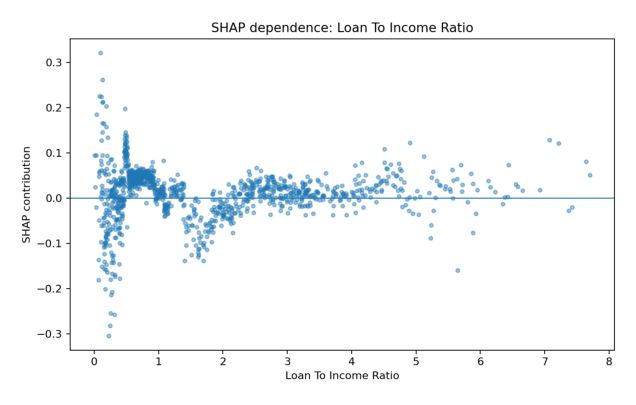

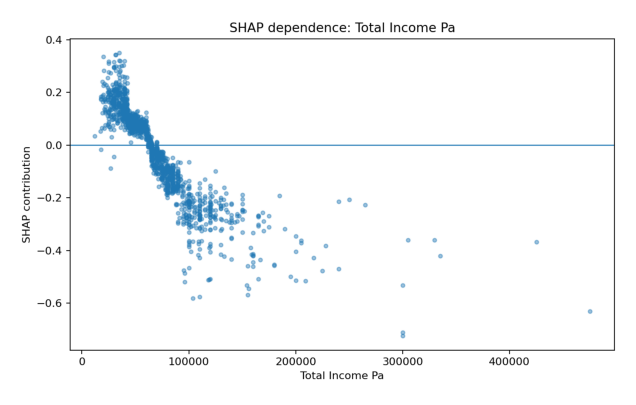

In [10]:
for feature in ["interest_rate", "loan_to_income_ratio", "total_income_pa"]:
    path = FIGURE_DIR / f"xai_shap_dependence_{feature}.png"
    if path.exists():
        img = plt.imread(path)
        plt.figure(figsize=(8, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.show()

## Local explanations for reviewed accounts

The next table explains high-risk accounts and borderline accounts just above the threshold. This is the type of explanation a risk analyst could use to understand why a borrower was sent to manual review.

In [11]:
high_risk_indices = score_series.sort_values(ascending=False).head(20).index.tolist()
closest_above_indices = score_series.loc[score_series.ge(artifacts.recommended_threshold)].sort_values().head(20).index.tolist()
local_candidate_indices = pd.Index(high_risk_indices + closest_above_indices).drop_duplicates().tolist()

missing_local = [idx for idx in local_candidate_indices if idx not in shap_df.index]
if missing_local:
    local_X = X_test.loc[missing_local]
    local_shap, _ = compute_tree_shap_values(artifacts.champion_model, local_X)
    shap_df = pd.concat([shap_df, local_shap], axis=0)

individual_explanations = individual_top_contributions(
    X_raw=X_test,
    identity=identity_test,
    shap_df=shap_df,
    scores=score_series,
    candidate_indices=local_candidate_indices,
    threshold=artifacts.recommended_threshold,
    top_n=5,
)

individual_explanations.head(15)

,user_id,record_sequence,defaulter,split,predicted_default_probability,operating_threshold,predicted_high_risk,top_positive_drivers,top_negative_drivers
0,2498303,1,1,test,0.883060,0.565,1,Interest Rate (+0.9124); Amount Missing Flag (...,Core Data Quality Issue Count (-0.2752); Has C...
1,2528142,1,1,test,0.882278,0.565,1,Amount Missing Flag (+0.8925); Interest Rate (...,Core Data Quality Issue Count (-0.2618); Broad...
2,2776421,1,0,test,0.881567,0.565,1,Amount Missing Flag (+0.9436); Interest Rate (...,Core Data Quality Issue Count (-0.2681); Broad...
3,2775991,1,1,test,0.879315,0.565,1,Amount Missing Flag (+0.8428); Interest Rate (...,Core Data Quality Issue Count (-0.2720); Has C...
4,2985700,1,1,test,0.875651,0.565,1,Interest Rate (+0.9011); Amount Missing Flag (...,Core Data Quality Issue Count (-0.2696); Broad...
5,2445803,1,1,test,0.875331,0.565,1,Interest Rate (+0.9974); Amount Missing Flag (...,Core Data Quality Issue Count (-0.2600); Total...
6,3082919,1,1,test,0.873559,0.565,1,Interest Rate (+0.8690); Amount Missing Flag (...,Core Data Quality Issue Count (-0.2603); Has C...
7,5197167,1,0,test,0.871635,0.565,1,Broad Data Quality Issue Count (+0.5980); Loan...,Amount Missing Flag (-0.1104); Total Income Pa...
8,3018328,1,0,test,0.870873,0.565,1,Interest Rate (+0.9339); Amount Missing Flag (...,Core Data Quality Issue Count (-0.2667); Broad...
9,3089821,1,0,test,0.870180,0.565,1,Interest Rate (+0.9890); Amount Missing Flag (...,Core Data Quality Issue Count (-0.2687); Broad...


## Anchor-like rules

Formal Anchor explanations require an additional explainer package and can be slow on larger tabular portfolios. For this portfolio version, we create **anchor-like** local rules using the top positive SHAP drivers and evaluate those rules against the full test split.

- **Coverage**: share of test accounts matching the rule.
- **Model high-risk precision**: share of covered accounts that the model also sends to review.
- **Observed default rate**: actual default rate among covered accounts.

In [12]:
anchor_rules = build_anchor_like_rules(
    X_reference=X_test,
    y_reference=y_test,
    scores_reference=score_series,
    X_explain=X_test,
    shap_explain=shap_df,
    candidate_indices=high_risk_indices[:10],
    threshold=artifacts.recommended_threshold,
    max_conditions=3,
)

anchor_rules

,row_index,predicted_default_probability,operating_threshold,rule,condition_count,coverage,covered_rows,model_high_risk_precision,observed_default_rate
0,55092,0.883060,0.565,Interest Rate >= 11.84 AND Amount Missing Flag...,3,0.003720,75,1.000000,0.293333
1,54297,0.882278,0.565,Amount Missing Flag = 1 AND Interest Rate >= 1...,3,0.003720,75,1.000000,0.293333
2,46549,0.881567,0.565,Amount Missing Flag = 1 AND Interest Rate >= 1...,3,0.003720,75,1.000000,0.293333
3,46539,0.879315,0.565,Amount Missing Flag = 1 AND Interest Rate >= 1...,3,0.003720,75,1.000000,0.293333
4,56813,0.875331,0.565,Interest Rate >= 11.84 AND Amount Missing Flag...,3,0.003720,75,1.000000,0.293333
5,36305,0.873559,0.565,Interest Rate >= 11.84 AND Amount Missing Flag...,3,0.003720,75,1.000000,0.293333
6,39808,0.875651,0.565,Interest Rate >= 11.84 AND Amount Missing Flag...,3,0.106333,2144,0.909515,0.212687
7,38600,0.870873,0.565,Interest Rate >= 11.84 AND Amount Missing Flag...,3,0.106333,2144,0.909515,0.212687
8,35628,0.870180,0.565,Interest Rate >= 11.84 AND Amount Missing Flag...,3,0.106333,2144,0.909515,0.212687
9,8365,0.871635,0.565,Broad Data Quality Issue Count < 2.00 AND Loan...,3,0.002133,43,0.837209,0.302326


## Counterfactual scenario analysis

Counterfactuals help answer: *What changes would reduce the model score for a selected high-risk borrower?*

This notebook uses controlled scenario analysis, not unconstrained synthetic generation. It tests pricing, affordability, and diagnostic historical scenarios while preserving the model's feature-engineering logic.

In [13]:
cf_candidate_indices = pd.Index(high_risk_indices[:5] + closest_above_indices[:10]).drop_duplicates().tolist()

counterfactual_scenarios = generate_counterfactual_scenarios(
    pipeline=artifacts.champion_model,
    X_candidates=X_test.loc[cf_candidate_indices],
    baseline_scores=score_series,
    threshold=artifacts.recommended_threshold,
    reference_df=X_test,
)

best_counterfactuals = best_counterfactual_per_account(counterfactual_scenarios)
best_counterfactuals

,row_index,scenario,action_type,baseline_probability,scenario_probability,probability_change,absolute_probability_reduction,operating_threshold,crosses_below_threshold
0,4972,Reduce interest rate to 8%,pricing_scenario,0.565111,0.317100,-0.248011,0.248011,0.565,True
1,16982,Reduce interest rate to 8%,pricing_scenario,0.565062,0.089502,-0.475559,0.475559,0.565,True
2,30793,Reduce interest rate to 8%,pricing_scenario,0.565198,0.296339,-0.268859,0.268859,0.565,True
3,39808,Reduce interest rate to 8%,pricing_scenario,0.875651,0.502437,-0.373214,0.373214,0.565,True
4,44808,Reduce interest rate to 8%,pricing_scenario,0.565229,0.195701,-0.369529,0.369529,0.565,True
5,46539,Reduce interest rate to 8%,pricing_scenario,0.879315,0.518149,-0.361166,0.361166,0.565,True
6,46549,Reduce interest rate to 8%,pricing_scenario,0.881567,0.686779,-0.194788,0.194788,0.565,False
7,50125,Reduce interest rate to 8%,pricing_scenario,0.565031,0.336781,-0.228249,0.228249,0.565,True
8,54297,Reduce interest rate to 8%,pricing_scenario,0.882278,0.588546,-0.293732,0.293732,0.565,False
9,55092,Reduce interest rate to 8%,pricing_scenario,0.883060,0.564197,-0.318863,0.318863,0.565,True


In [14]:
counterfactual_scenarios.head(30)

,row_index,scenario,action_type,baseline_probability,scenario_probability,probability_change,absolute_probability_reduction,operating_threshold,crosses_below_threshold
0,4972,Reduce interest rate to 8%,pricing_scenario,0.565111,0.317100,-0.248011,0.248011,0.565,True
1,4972,Reduce exposure 20% and increase verified inco...,combined_affordability_scenario,0.565111,0.512832,-0.052279,0.052279,0.565,True
2,4972,Increase verified annual income by 30%,affordability_scenario,0.565111,0.520124,-0.044986,0.044986,0.565,True
3,4972,Increase verified annual income by 20%,affordability_scenario,0.565111,0.527096,-0.038015,0.038015,0.565,True
4,4972,Increase verified annual income by 10%,affordability_scenario,0.565111,0.558369,-0.006742,0.006742,0.565,True
5,4972,Reduce requested/exposure amount by 30%,affordability_scenario,0.565111,0.571411,0.006300,-0.006300,0.565,False
6,4972,Reduce requested/exposure amount by 20%,affordability_scenario,0.565111,0.581511,0.016401,-0.016401,0.565,False
7,4972,Reduce requested/exposure amount by 10%,affordability_scenario,0.565111,0.583510,0.018400,-0.018400,0.565,False
8,16982,Reduce interest rate to 8%,pricing_scenario,0.565062,0.089502,-0.475559,0.475559,0.565,True
9,16982,Reduce exposure 20% and increase verified inco...,combined_affordability_scenario,0.565062,0.470952,-0.094110,0.094110,0.565,True


## Save XAI outputs

These outputs feed the governance notebook and the final stakeholder summary.

In [15]:
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

global_importance.to_csv(TABLE_DIR / "xai_global_shap_importance.csv", index=False)
grouped_importance.to_csv(TABLE_DIR / "xai_grouped_shap_importance.csv", index=False)
probability_deciles.to_csv(TABLE_DIR / "xai_probability_decile_profile.csv", index=False)
individual_explanations.to_csv(TABLE_DIR / "xai_individual_local_explanations.csv", index=False)
anchor_rules.to_csv(TABLE_DIR / "xai_anchor_like_rules.csv", index=False)
counterfactual_scenarios.to_csv(TABLE_DIR / "xai_counterfactual_scenarios.csv", index=False)
best_counterfactuals.to_csv(TABLE_DIR / "xai_best_counterfactual_per_account.csv", index=False)

{
    "global_shap": str(TABLE_DIR / "xai_global_shap_importance.csv"),
    "grouped_shap": str(TABLE_DIR / "xai_grouped_shap_importance.csv"),
    "local_explanations": str(TABLE_DIR / "xai_individual_local_explanations.csv"),
    "anchor_rules": str(TABLE_DIR / "xai_anchor_like_rules.csv"),
    "counterfactuals": str(TABLE_DIR / "xai_counterfactual_scenarios.csv"),
}

{'global_shap': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\tables\\xai_global_shap_importance.csv',
 'grouped_shap': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\tables\\xai_grouped_shap_importance.csv',
 'local_explanations': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\tables\\xai_individual_local_explanations.csv',
 'anchor_rules': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\tables\\xai_anchor_like_rules.csv',
 'counterfactuals': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\tables\\xai_counterfactual_scenarios.csv'}

### Key Explainability Outputs

| Area | Result |
|---|---:|
| Champion model | `xgboost_weighted` |
| Operating threshold | `0.565` |
| Test rows | 20,163 |
| Test default rate | 9.0413% |
| Review rate at operating threshold | 29.11% |
| SHAP sample rows | 1,500 |
| Transformed feature count | 47 |

### Top SHAP Drivers

The top SHAP drivers are business-reasonable and align with expected credit-risk behaviour:

| Rank | SHAP Driver |
|---:|---|
| 1 | `interest_rate` |
| 2 | `amount_missing_flag` |
| 3 | `broad_data_quality_issue_count` |
| 4 | `total_income_pa` |
| 5 | `core_data_quality_issue_count` |
| 6 | `loan_to_income_band` |
| 7 | `high_interest_flag` |
| 8 | `tenure_years` |
| 9 | `loan_category` |
| 10 | `amount` |
| 11 | `loan_to_income_ratio` |
| 12 | `home` |

### Explainability Direction

These outputs support the original Explainable AI project direction:

- Global SHAP feature importance
- SHAP dependence-style analysis
- Local borrower-level explanations
- Anchor-style explanations
- Counterfactual scenario analysis

### Governance Note

The counterfactual output shows that, for many accounts, the strongest model sensitivity scenario is:

> Reduce interest rate to 8%

This is acceptable for model sensitivity analysis, but it should not be presented as customer advice.

Interest rate may reflect risk-based pricing, underwriting policy, contractual terms, or broader lending strategy. Therefore, Notebook 09 should explicitly label counterfactuals as diagnostic scenarios only, not as recommended borrower actions or credit-policy advice.

## Notebook 08 conclusions

Carry these decisions forward:

1. SHAP global importance identifies the strongest model drivers and should be compared against business expectations from Notebook 04.
2. Local SHAP explanations give borrower-level reason codes for high-risk and borderline cases.
3. Anchor-like rules translate selected high-risk decisions into auditable business conditions.
4. Counterfactual scenarios are useful for model understanding, but non-actionable historical variables must not be communicated as customer recommendations.
5. Notebook 09 should convert these findings into a model card, validation summary, governance controls, and monitoring plan.